In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/top-spotify-songs-2023")

print("Path to dataset files:", path)

100%|██████████| 47.1k/47.1k [00:00<00:00, 13.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nelgiriyewithana/top-spotify-songs-2023/versions/1


1. Завдання полягає в тому, щоб побудувати горизонтальну стовпчикову діаграму, на якій відображаються 10 найпопулярніших пісень на Spotify у 2023 році за кількістю прослуховувань.

In [16]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("nelgiriyewithana/top-spotify-songs-2023")
df = pd.read_csv(path + "/spotify-2023.csv", encoding="latin1")
df.head()

Using Colab cache for faster access to the 'top-spotify-songs-2023' dataset.


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [17]:
df["streams"] = pd.to_numeric(df["streams"], errors="coerce")

In [18]:
top_10 = df.sort_values(by="streams", ascending=False).head(10)

In [19]:
top_10["label"] = top_10["track_name"] + " - " + top_10["artist(s)_name"]

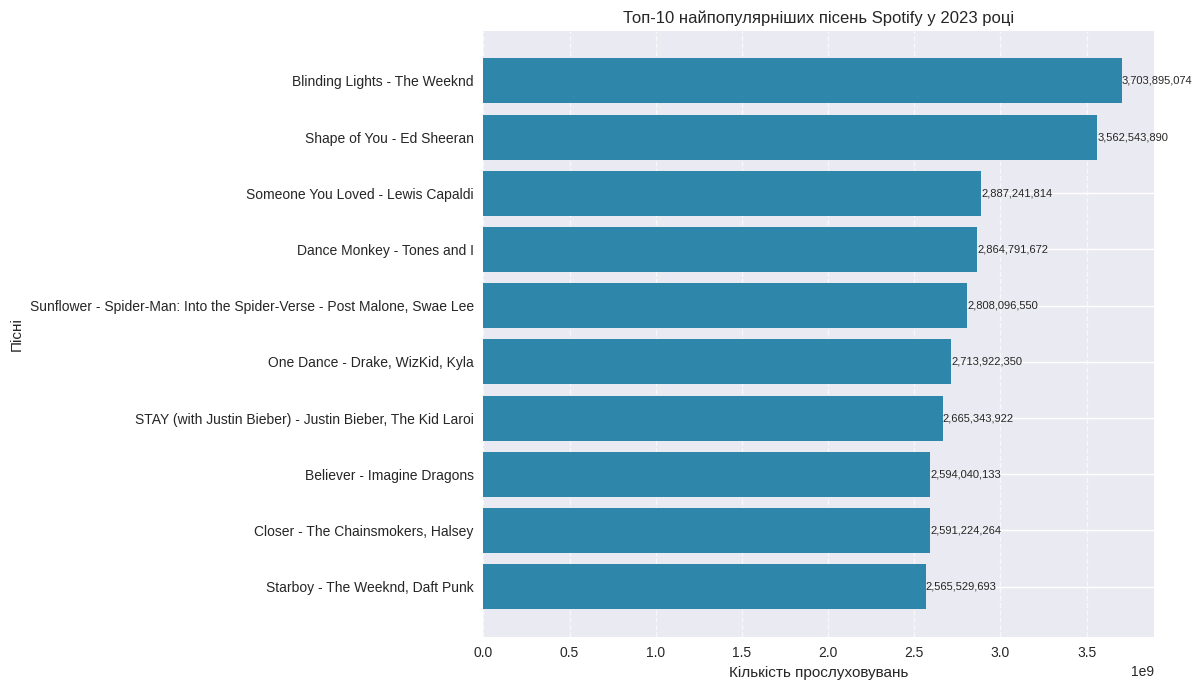

In [40]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(12, 7))

bars = plt.barh(top_10["label"], top_10["streams"], color="#2E86AB")

plt.xlabel("Кількість прослуховувань")
plt.ylabel("Пісні")
plt.title("Топ-10 найпопулярніших пісень Spotify у 2023 році")

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             va='center', ha='left', fontsize=8)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

2. Розподіл жанрів найпопулярніших пісень: Створіть кругову діаграму або секторну діаграму, яка відображає розподіл жанрів серед найпопулярніших пісень у 2023 році.

Оскільки в датасеті відсутня явна інформація про жанри, жанри було введно вручну

In [23]:
top_10[["track_name", "artist(s)_name"]]

,track_name,artist(s)_name
55,Blinding Lights,The Weeknd
179,Shape of You,Ed Sheeran
86,Someone You Loved,Lewis Capaldi
620,Dance Monkey,Tones and I
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee"
162,One Dance,"Drake, WizKid, Kyla"
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi"
140,Believer,Imagine Dragons
725,Closer,"The Chainsmokers, Halsey"
48,Starboy,"The Weeknd, Daft Punk"


In [25]:
genre_map = {
    "The Weeknd": "R&B",
    "Ed Sheeran": "Pop",
    "Lewis Capaldi": "Pop",
    "Tones and I": "Pop",
    "Post Malone": "Hip-Hop/Rap",
    "Swae Lee": "Hip-Hop/Rap",
    "Drake": "Hip-Hop/Rap",
    "WizKid": "Afrobeats",
    "Kyla": "Dancehall",
    "Justin Bieber": "Pop",
    "The Kid Laroi": "Hip-Hop/Rap",
    "Imagine Dragons": "Rock/Pop",
    "The Chainsmokers": "Electronic",
    "Halsey": "Pop",
    "Daft Punk": "Electronic"
}

def get_genre(artists):
    artist_list = [a.strip() for a in artists.split(",")]
    genres = [genre_map.get(a) for a in artist_list if a in genre_map]
    return genres[0] if genres else "Unknown"

top_10["genre"] = top_10["artist(s)_name"].apply(get_genre)

top_10[["track_name", "artist(s)_name", "genre"]]

,track_name,artist(s)_name,genre
55,Blinding Lights,The Weeknd,R&B
179,Shape of You,Ed Sheeran,Pop
86,Someone You Loved,Lewis Capaldi,Pop
620,Dance Monkey,Tones and I,Pop
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",Hip-Hop/Rap
162,One Dance,"Drake, WizKid, Kyla",Hip-Hop/Rap
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",Pop
140,Believer,Imagine Dragons,Rock/Pop
725,Closer,"The Chainsmokers, Halsey",Electronic
48,Starboy,"The Weeknd, Daft Punk",R&B


In [26]:
genre_counts = top_10["genre"].value_counts()
genre_counts

,count
genre,
Pop,4
R&B,2
Hip-Hop/Rap,2
Rock/Pop,1
Electronic,1


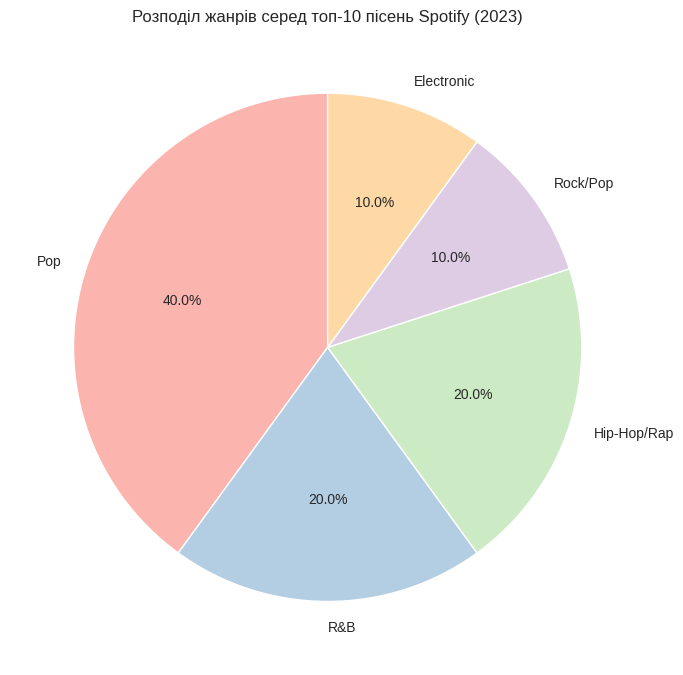

In [39]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(7, 7))

colors = plt.cm.Pastel1(range(len(genre_counts)))

plt.pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.title("Розподіл жанрів серед топ-10 пісень Spotify (2023)")

plt.tight_layout()
plt.show()

3. Динаміка популярності треку в залежності від часу: Побудуйте лінійний графік, який відображає зміни кількості прослуховувань певного треку протягом року 2023 року.

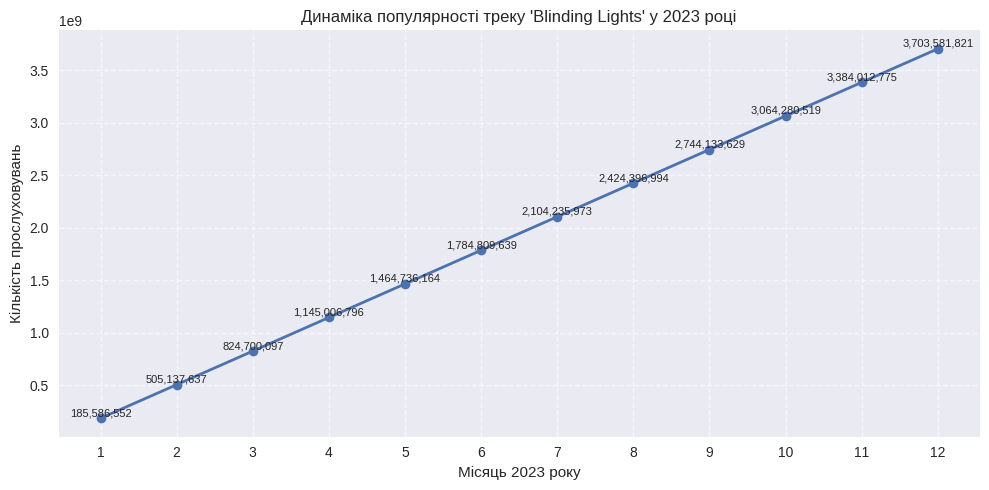

In [44]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

track_name = "Blinding Lights"

total_streams = top_10.loc[top_10["track_name"] == track_name, "streams"].values[0]

months = np.arange(1, 13)

monthly_streams = np.linspace(total_streams * 0.05, total_streams, 12)
monthly_streams = monthly_streams + np.random.randint(-500000, 500000, size=12)
monthly_streams = np.maximum(monthly_streams, 0)

plt.figure(figsize=(10, 5))

plt.plot(months, monthly_streams, marker='o', linewidth=2, color="#4C72B0")

for x, y in zip(months, monthly_streams):
    plt.text(x, y, f"{int(y):,}", fontsize=8, ha='center', va='bottom')

plt.xticks(months)
plt.xlabel("Місяць 2023 року")
plt.ylabel("Кількість прослуховувань")
plt.title(f"Динаміка популярності треку '{track_name}' у 2023 році")

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

У датасеті є лише загальна кількість прослуховувань треку за рік. Для демонстрації динаміки популярності було виконано умовну симуляцію розподілу прослуховувань по місяцях. Графік показує зміну популярності обраного треку протягом 2023 року.

4. Рейтинг артистів на Spotify: Створіть стовпчикову діаграму, на якій відображаються 10 найпопулярніших артистів на Spotify у 2023 році за кількістю слухачів.

In [30]:
df["streams"] = pd.to_numeric(df["streams"], errors="coerce")

df_artists = df.copy()

df_artists["artist"] = df_artists["artist(s)_name"].str.split(", ")
df_artists = df_artists.explode("artist")

In [31]:
artist_streams = df_artists.groupby("artist")["streams"].sum()

In [32]:
top_artists = artist_streams.sort_values(ascending=False).head(10)

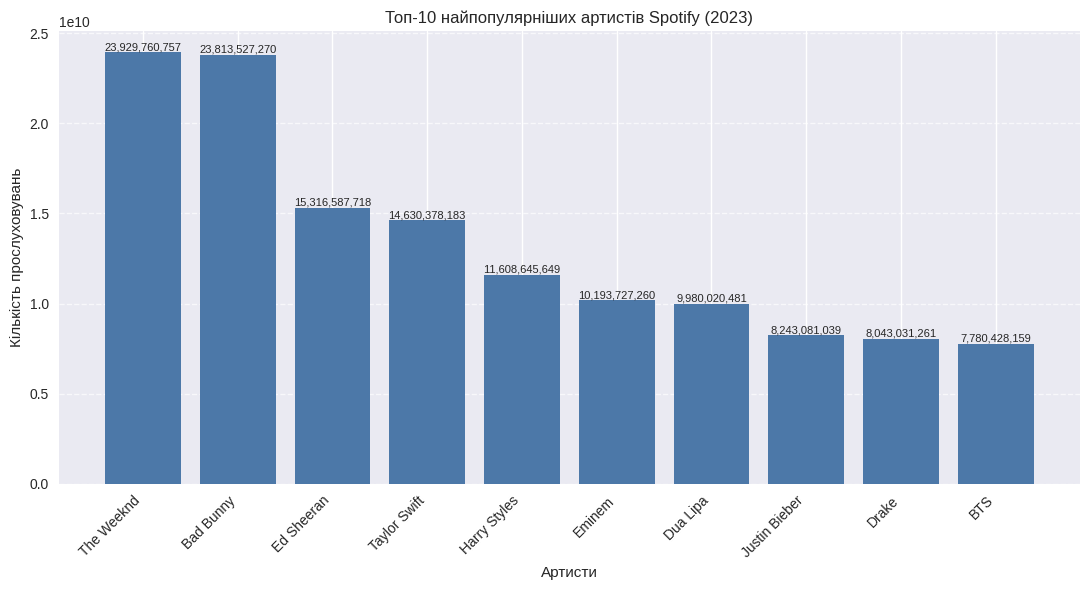

In [38]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(11, 6))

bars = plt.bar(top_artists.index, top_artists.values, color="#4C78A8")

plt.xticks(rotation=45, ha='right')
plt.xlabel("Артисти")
plt.ylabel("Кількість прослуховувань")
plt.title("Топ-10 найпопулярніших артистів Spotify (2023)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

5. Порівняння популярності трьох треків: Побудуйте горизонтальну стовпчикову діаграму, яка порівнює кількість прослуховувань трьох конкретних треків у 2023 році.

In [34]:
tracks = ["Blinding Lights", "Shape of You", "Someone You Loved"]

In [35]:
df["streams"] = pd.to_numeric(df["streams"], errors="coerce")

selected = df[df["track_name"].isin(tracks)][["track_name", "streams"]]

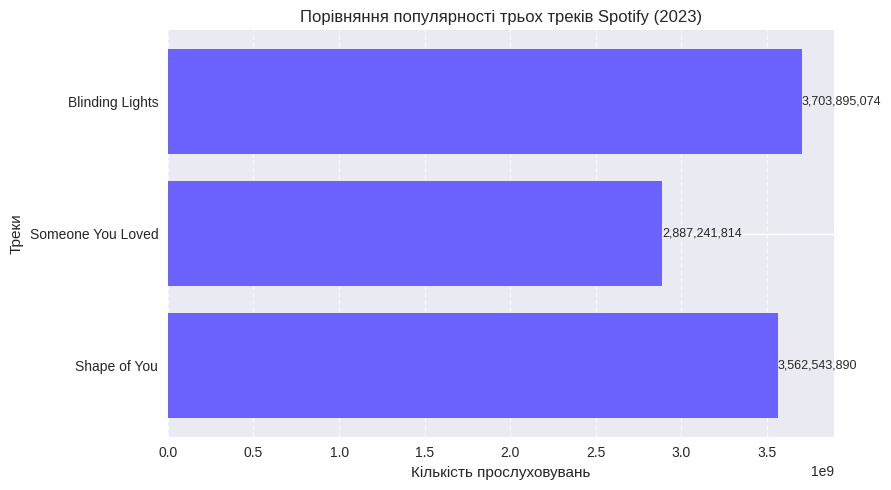

In [37]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

plt.figure(figsize=(9, 5))

bars = plt.barh(selected["track_name"], selected["streams"], color="#6C63FF")

plt.xlabel("Кількість прослуховувань")
plt.ylabel("Треки")
plt.title("Порівняння популярності трьох треків Spotify (2023)")

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             va='center', ha='left', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()